# Phase 2 — Notebook 10 · LOSO temporal controls on the ultimate CNN design

**Goal.** The time-shuffled and amplitude-only controls were originally run only
on the simple Design-A trace-only CNN (NB 01, single-session GKF). This notebook
re-runs them on the **headline CNN architecture** — hash-aware Design B with
attention pooling (the NB 08 model) — under **LOSO**, so the controls are:

- **architecture-matched** to the CNN we actually report, and
- **population-matched** to the Tier G / DeepSets headline (5 balanced sessions).

**Three conditions, identical architecture & protocol:**

| Condition | Trace input | What it tests |
|-----------|-------------|---------------|
| `intact`         | real trial-averaged calcium trace            | full model |
| `time_shuffled`  | timepoints permuted within each trace        | is temporal **order** used? |
| `amplitude_only` | trace replaced by a flat line at its mean    | is anything beyond **scalar amplitude** used? |

If `intact ≈ time_shuffled ≈ amplitude_only`, the CNN is amplitude-equivalent —
temporal kinetics are not the source of its layer signal, even with the
hash-aware attention architecture.

**Population.** 5 balanced sessions: `5_6, 5_7, 6_2, 6_4, 6_6` (6_7 excluded so
this matches the Tier G headline population). Consistent neurons, oracle hashes,
E1 trial-averaged traces.

**Writes.** `data/processed/results/phase2_loso_temporal_controls.parquet`


## 0 · Environment

In [1]:
import os, sys, time, warnings
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.config import PROCESSED_RESULTS_DIR
from src.data.loaders import load_working_pop
from src.features.raw_traces import (
    remove_mismatch_neurons,
    build_pooled_e1,
    MAX_TRACE_LEN,
    load_oracle_hashes,
)
from src.models.cnn import LAYER_CLASSES
from src.models.cnn_deepsets import (
    HashAwareDeepSetsTraceCNN,
    build_e1_neuron_tensors_with_hashes,
    train_design_b_hash_fold,
    predict_neuron_proba_hash,
    neuron_score_design_b,
)

warnings.filterwarnings('ignore', category=UserWarning)

# 5 balanced sessions — 6_7 dropped to match the Tier G / DeepSets headline population
BALANCED_SESSIONS = ['5_6', '5_7', '6_2', '6_4', '6_6']

SEED         = 42
VAL_FRACTION = 0.15
MAX_EPOCHS   = 50
PATIENCE     = 8
BATCH_SIZE   = 32
TRACE_EMBED  = 64
HASH_EMBED   = 16
ROW_HIDDEN   = 64
HEAD_HIDDEN  = 64
DROPOUT      = 0.25
POOL         = 'attention'          # the headline pool

# the three temporal-control conditions
CONTROLS = ['intact', 'time_shuffled', 'amplitude_only']
CONTROL_SEED = 1234                 # one global seed for the trace transforms

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device          : {DEVICE}')
print(f'Sessions (LOSO) : {BALANCED_SESSIONS}')
print(f'Architecture    : HashAwareDeepSetsTraceCNN, pool={POOL}')
print(f'Conditions      : {CONTROLS}')
print(f'Training caps   : max_epochs={MAX_EPOCHS}, patience={PATIENCE}, batch_size={BATCH_SIZE}')


Device          : mps
Sessions (LOSO) : ['5_6', '5_7', '6_2', '6_4', '6_6']
Architecture    : HashAwareDeepSetsTraceCNN, pool=attention
Conditions      : ['intact', 'time_shuffled', 'amplitude_only']
Training caps   : max_epochs=50, patience=8, batch_size=32


## 1 · Population & pooled E1 dataset

Same construction as NB 08, but restricted to the 5 balanced sessions.

In [2]:
units_raw = load_working_pop()
units_clean, mismatch_report = remove_mismatch_neurons(units_raw, verbose=False)
df_pool = build_pooled_e1(BALANCED_SESSIONS, units_clean, verbose=True)

# Drop any neuron with incomplete oracle coverage (set-tensor build needs uniform 116)
cov = df_pool.groupby('nucleus_id')['condition_hash'].nunique()
incomplete = cov[cov < 116].index.tolist()
if incomplete:
    print(f'\n⚠️  Dropping {len(incomplete)} neurons with incomplete oracle coverage.')
    df_pool = df_pool[~df_pool['nucleus_id'].isin(incomplete)].reset_index(drop=True)

n_neurons = df_pool['nucleus_id'].nunique()
print(f'\nFinal pooled E1: {n_neurons} neurons × 116 hashes = {len(df_pool):,} rows')

# Per-neuron metadata (control transforms only touch the trace column, not these)
neurons_df = (df_pool[['nucleus_id', 'layer_label', 'session_key']]
              .drop_duplicates().reset_index(drop=True))
table = neurons_df.groupby(['session_key', 'layer_label']).size().unstack(fill_value=0)
table['total'] = table.sum(axis=1)
print('\nPer-session per-layer composition (LOSO test-set sizes):')
print(table.to_string())


Pooling 5 sessions: ['5_6', '5_7', '6_2', '6_4', '6_6']
  Population (mismatch-clean): 3545 neurons
session_key
5_6    685
5_7    696
6_2    734
6_4    824
6_6    606

  Pooled E1 rows: 411,220
  Neurons with data: 3,545
  Oracle coverage per neuron: min=116 median=116 max=116

  Per-session row count:
session_key
5_6    79460
5_7    80736
6_2    85144
6_4    95584
6_6    70296

Final pooled E1: 3545 neurons × 116 hashes = 411,220 rows

Per-session per-layer composition (LOSO test-set sizes):
layer_label  L2/3   L4   L5  L6  total
session_key                           
5_6           151  249  189  96    685
5_7           184  284  147  81    696
6_2           268  280  153  33    734
6_4           452  122  200  50    824
6_6           401   24  152  29    606


## 2 · Hash vocabulary

In [3]:
oracle_hashes, oracle_by_family = load_oracle_hashes()
HASH_VOCAB = sorted(oracle_hashes)
N_HASHES   = len(HASH_VOCAB)
assert N_HASHES == 116
print(f'Hash vocabulary: {N_HASHES} oracle hashes')


Hash vocabulary: 116 oracle hashes


## 3 · Temporal-control transforms

The two controls mirror `src.features.raw_traces.make_time_shuffled_traces`
and `make_amplitude_only_traces`, but are applied **per trace** on the
`response_avg` column of the pooled dataframe — before tensorisation — so they
work regardless of trace length and propagate consistently into train / val /
test through the standard tensor build.

- **`time_shuffled`** — each trace's timepoints are permuted independently
  (`rng.shuffle`). Marginal amplitude distribution preserved, temporal order
  destroyed.
- **`amplitude_only`** — each trace replaced by a flat line at its own mean.
  Only the scalar amplitude survives; all temporal structure removed.


In [4]:
def apply_trace_control(df, control, seed=CONTROL_SEED):
    '''Return a copy of df with response_avg transformed by the chosen control.'''
    if control == 'intact':
        return df.copy()

    df2 = df.copy()
    rng = np.random.default_rng(seed)

    if control == 'time_shuffled':
        new_traces = []
        for t in df['response_avg']:
            t = np.asarray(t, dtype=np.float32).copy()
            rng.shuffle(t)                       # in-place permutation of timepoints
            new_traces.append(t)
        df2['response_avg'] = new_traces

    elif control == 'amplitude_only':
        new_traces = []
        for t in df['response_avg']:
            t = np.asarray(t, dtype=np.float32)
            new_traces.append(np.full_like(t, float(t.mean())))
        df2['response_avg'] = new_traces

    else:
        raise ValueError(f'unknown control: {control!r}')

    return df2

# sanity check on a single trace
_t = np.asarray(df_pool['response_avg'].iloc[0], dtype=np.float32)
_s = apply_trace_control(df_pool.iloc[:1], 'time_shuffled')['response_avg'].iloc[0]
_a = apply_trace_control(df_pool.iloc[:1], 'amplitude_only')['response_avg'].iloc[0]
print(f'intact   : mean={_t.mean():.4f}  std={_t.std():.4f}  len={len(_t)}')
print(f'shuffled : mean={_s.mean():.4f}  std={_s.std():.4f}  (mean/std preserved, order destroyed)')
print(f'amp-only : mean={_a.mean():.4f}  std={_a.std():.4f}  (flat — std≈0)')


intact   : mean=0.1764  std=0.9284  len=75
shuffled : mean=0.1764  std=0.9284  (mean/std preserved, order destroyed)
amp-only : mean=0.1764  std=0.0000  (flat — std≈0)


## 4 · LOSO runner

`stratified_val_split` and the per-fit logic are copied from NB 08. The runner
is wrapped so it can be called once per control condition with its own
tensor stack.

In [5]:
def stratified_val_split(train_indices, y_str, fit_seed, val_fraction=VAL_FRACTION):
    '''Stratified-by-layer random val split of training neurons (NB 08 logic).'''
    rng = np.random.default_rng(fit_seed)
    val_picks = []
    for c in LAYER_CLASSES:
        cls_idx = train_indices[y_str[train_indices] == c]
        if len(cls_idx) == 0:
            continue
        n_val = max(1, int(round(len(cls_idx) * val_fraction)))
        if n_val >= len(cls_idx):
            n_val = max(1, len(cls_idx) - 1)
        val_picks.append(rng.choice(cls_idx, size=n_val, replace=False))
    val_idx   = np.sort(np.concatenate(val_picks))
    train_idx = np.setdiff1d(train_indices, val_idx, assume_unique=False)
    return train_idx, val_idx


def run_loso_for_condition(control, only_sessions=None):
    '''Build tensors for one control condition and run its LOSO fits.

    If `only_sessions` is given, only those held-out sessions are run
    (skip-on-cache). Returns a list of per-held-out-session score dicts.
    '''
    sessions_to_run = list(only_sessions) if only_sessions is not None else list(BALANCED_SESSIONS)
    print(f'\n{"="*72}')
    print(f'CONDITION: {control}   ({len(sessions_to_run)} fold(s) to run)')
    print(f'{"="*72}')

    # Apply the trace control, then build the set-tensors exactly as NB 08
    df_ctrl = apply_trace_control(df_pool, control, seed=CONTROL_SEED)
    X, mask, y_str, nids, hash_ids, hash_vocab = build_e1_neuron_tensors_with_hashes(
        df_ctrl, pad_to=MAX_TRACE_LEN, hash_vocab=HASH_VOCAB,
    )
    assert hash_vocab == HASH_VOCAB
    session_lookup = neurons_df.set_index('nucleus_id')['session_key'].to_dict()
    session_of = np.array([session_lookup[int(n)] for n in nids])
    print(f'  X: {X.shape}  dtype={X.dtype}')

    scores = []
    t0 = time.time()
    for test_session in sessions_to_run:
        fit_index = BALANCED_SESSIONS.index(test_session)   # keep seeds reproducible
        ti = time.time()
        test_idx       = np.where(session_of == test_session)[0]
        train_pool_idx = np.where(session_of != test_session)[0]
        train_idx, val_idx = stratified_val_split(
            train_pool_idx, y_str, fit_seed=SEED + fit_index + 1000,
            val_fraction=VAL_FRACTION,
        )
        assert (not (set(train_idx) & set(val_idx))) and \
               (not (set(train_idx) & set(test_idx))) and \
               (not (set(val_idx) & set(test_idx))), 'neuron leakage detected'

        X_tr, M_tr, y_tr = X[train_idx], mask[train_idx], y_str[train_idx]
        X_va, M_va, y_va = X[val_idx],   mask[val_idx],   y_str[val_idx]
        X_te, M_te, y_te = X[test_idx],  mask[test_idx],  y_str[test_idx]

        model, history = train_design_b_hash_fold(
            X_tr, M_tr, y_tr,
            X_va, M_va, y_va,
            hash_ids=hash_ids,
            n_hashes=N_HASHES,
            in_channels=1, n_classes=4,
            trace_embed=TRACE_EMBED, hash_embed=HASH_EMBED,
            row_hidden=ROW_HIDDEN, head_hidden=HEAD_HIDDEN,
            dropout=DROPOUT, kernel_size=5,
            pool=POOL,
            batch_size=BATCH_SIZE,
            max_epochs=MAX_EPOCHS, patience=PATIENCE,
            lr=1e-3, weight_decay=1e-4,
            seed=SEED + fit_index,
            device=DEVICE,
            verbose=False,
        )

        test_probs = predict_neuron_proba_hash(
            model, X_te, hash_ids, mask=M_te,
            batch_size=BATCH_SIZE, device=DEVICE,
        )
        score = neuron_score_design_b(y_te, test_probs, classes=np.array(LAYER_CLASSES))
        score['control']       = control
        score['test_session']  = test_session
        score['fit_index']     = fit_index
        score['n_test']        = len(test_idx)
        score['n_train']       = len(train_idx)
        score['n_val']         = len(val_idx)
        score['best_epoch']    = int(np.argmax([h['val_bal_acc'] for h in history])) + 1
        scores.append(score)

        ba  = score['balanced_accuracy']
        pcr = score['per_class_recall']
        print(f'  held out {test_session} | n_test={score["n_test"]:4d} | '
              f'bal_acc={ba:.4f} | best_ep={score["best_epoch"]:>2d} | '
              f'recall: ' + ' '.join(f'{c}={pcr[c]:.2f}' for c in LAYER_CLASSES)
              + f'  ({time.time()-ti:.1f}s)')

    print(f'  -> {control}: total {(time.time()-t0)/60:.1f} min')
    return scores

print('LOSO runner ready (supports only_sessions= for skip-on-cache).')


LOSO runner ready (supports only_sessions= for skip-on-cache).


## 5 · Run all 3 conditions × 5 LOSO fits

15 CNN trainings total. On CPU this is slow — expect tens of minutes; on
GPU / MPS it is much faster.

In [6]:
# Skip-on-cache training loop.
# Loads any already-saved parquet, trains only the missing (control, session)
# folds, and saves incrementally after each condition. A re-run on a fresh
# kernel with a complete cache trains nothing.
RESULTS_PATH = PROCESSED_RESULTS_DIR / 'phase2_loso_temporal_controls.parquet'
SCALAR_TYPES = (str, bool, int, float, np.integer, np.floating)

def _flatten_score(sc):
    row = {}
    for k, v in sc.items():
        if k == 'per_class_recall' and isinstance(v, dict):
            for cls, r in v.items():
                row['recall_' + str(cls).replace('/', '_')] = float(r)
        elif isinstance(v, SCALAR_TYPES):
            row[k] = v
    return row

if RESULTS_PATH.exists():
    all_rows = pd.read_parquet(RESULTS_PATH).to_dict('records')
    done = {(r['control'], r['test_session']) for r in all_rows}
    print(f'Loaded {len(all_rows)} cached fold rows.  Done: {sorted(done)}')
else:
    all_rows = []
    done = set()

for control in CONTROLS:
    pending = [s for s in BALANCED_SESSIONS if (control, s) not in done]
    if not pending:
        print(f'[{control}] all {len(BALANCED_SESSIONS)} folds cached -- skipping.')
        continue
    new_scores = run_loso_for_condition(control, only_sessions=pending)
    for sc in new_scores:
        all_rows.append(_flatten_score(sc))
        done.add((sc['control'], sc['test_session']))
    pd.DataFrame(all_rows).to_parquet(RESULTS_PATH)   # incremental save per condition
    print(f'  saved -> {RESULTS_PATH}  ({len(all_rows)} rows total)')

df_scores = pd.DataFrame(all_rows)
print(f'\nTotal: {len(df_scores)} rows ({len(CONTROLS)} conditions x {len(BALANCED_SESSIONS)} folds).')
print(f'Columns: {list(df_scores.columns)}')
df_scores[['control','test_session','balanced_accuracy','macro_f1','n_test','best_epoch']]


Loaded 15 cached fold rows.  Done: [('amplitude_only', '5_6'), ('amplitude_only', '5_7'), ('amplitude_only', '6_2'), ('amplitude_only', '6_4'), ('amplitude_only', '6_6'), ('intact', '5_6'), ('intact', '5_7'), ('intact', '6_2'), ('intact', '6_4'), ('intact', '6_6'), ('time_shuffled', '5_6'), ('time_shuffled', '5_7'), ('time_shuffled', '6_2'), ('time_shuffled', '6_4'), ('time_shuffled', '6_6')]
[intact] all 5 folds cached -- skipping.
[time_shuffled] all 5 folds cached -- skipping.
[amplitude_only] all 5 folds cached -- skipping.

Total: 15 rows (3 conditions x 5 folds).
Columns: ['balanced_accuracy', 'macro_f1', 'n_neurons', 'control', 'test_session', 'fit_index', 'n_test', 'n_train', 'n_val', 'best_epoch']


,control,test_session,balanced_accuracy,macro_f1,n_test,best_epoch
0,intact,5_6,0.564478,0.520426,685,13
1,intact,5_7,0.580536,0.501061,696,14
2,intact,6_2,0.560885,0.534397,734,35
3,intact,6_4,0.487361,0.408699,824,9
4,intact,6_6,0.481175,0.357124,606,22
5,time_shuffled,5_6,0.572282,0.533318,685,26
6,time_shuffled,5_7,0.590321,0.552991,696,32
7,time_shuffled,6_2,0.577871,0.445800,734,6
8,time_shuffled,6_4,0.466926,0.327588,824,8
9,time_shuffled,6_6,0.528375,0.358571,606,21


## 6 · Summary — does temporal order matter for the headline CNN?

In [7]:
# Read from the saved parquet so this cell works on a fresh kernel
# (no need to re-run the training cell).
df_scores = pd.read_parquet(PROCESSED_RESULTS_DIR / 'phase2_loso_temporal_controls.parquet')

summary = (df_scores.groupby('control')['balanced_accuracy']
           .agg(['mean', 'std', 'min', 'max'])
           .reindex(CONTROLS))
print('=== LOSO balanced accuracy by condition (mean across 5 held-out sessions) ===')
print(summary.round(4).to_string())

intact_mean = summary.loc['intact', 'mean']
print()
for control in ['time_shuffled', 'amplitude_only']:
    delta = summary.loc[control, 'mean'] - intact_mean
    print(f'  Delta ({control:<15} - intact) = {delta:+.4f}')

print()
print('Interpretation guide:')
print('  |Delta| <~ 0.01  -> condition matches intact -> that info is NOT what the CNN uses')
print('  Delta clearly negative -> the CNN does rely on that information')


=== LOSO balanced accuracy by condition (mean across 5 held-out sessions) ===
                  mean     std     min     max
control                                       
intact          0.5349  0.0468  0.4812  0.5805
time_shuffled   0.5472  0.0506  0.4669  0.5903
amplitude_only  0.5189  0.0688  0.4176  0.5893

  Delta (time_shuffled   - intact) = +0.0123
  Delta (amplitude_only  - intact) = -0.0160

Interpretation guide:
  |Delta| <~ 0.01  -> condition matches intact -> that info is NOT what the CNN uses
  Delta clearly negative -> the CNN does rely on that information


## 7 · Figure — three-condition comparison

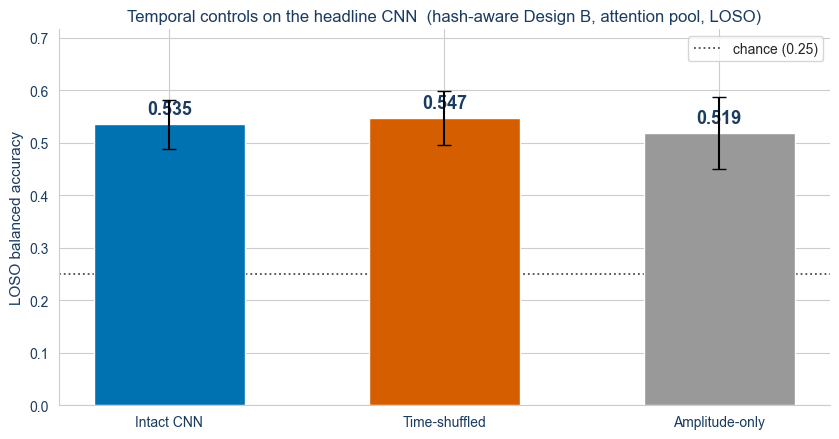

Saved: reports/figures/phase2_loso_temporal_controls.png


In [8]:
import seaborn as sns
sns.set_style('whitegrid')

# Wong CVD-safe palette
W_BLUE, W_VERMILLION, W_GRAY = '#0072B2', '#D55E00', '#999999'
NAVY = '#1B3B5F'
cond_color = {'intact': W_BLUE, 'time_shuffled': W_VERMILLION, 'amplitude_only': W_GRAY}
cond_label = {'intact': 'Intact CNN', 'time_shuffled': 'Time-shuffled',
              'amplitude_only': 'Amplitude-only'}

fig, ax = plt.subplots(figsize=(8.5, 4.5))
means = [summary.loc[c, 'mean'] for c in CONTROLS]
stds  = [summary.loc[c, 'std']  for c in CONTROLS]
colors = [cond_color[c] for c in CONTROLS]

bars = ax.bar([cond_label[c] for c in CONTROLS], means, yerr=stds,
              color=colors, edgecolor='white', linewidth=1.0, width=0.55,
              capsize=5, zorder=3)
for b, m in zip(bars, means):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.012,
            f'{m:.3f}', ha='center', va='bottom', fontsize=13,
            color=NAVY, fontweight='bold')

ax.axhline(0.25, ls=':', color='black', alpha=0.7, lw=1.3, label='chance (0.25)')
ax.set_ylim(0.0, max(means) + max(stds) + 0.10)
ax.set_ylabel('LOSO balanced accuracy', fontsize=11, color=NAVY)
ax.set_title('Temporal controls on the headline CNN  (hash-aware Design B, attention pool, LOSO)',
             fontsize=12, color=NAVY)
ax.tick_params(colors=NAVY)
ax.legend(loc='upper right', fontsize=10)
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
for sp in ['left', 'bottom']: ax.spines[sp].set_color('#CCCCCC')

plt.tight_layout()
from src.config import FIGURES_DIR
fig_path = FIGURES_DIR / 'phase2_loso_temporal_controls.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {fig_path}')


## 7b · Per-session comparison

The summary bar chart above collapses across the five held-out sessions. This
grouped chart keeps them separate -- one group per held-out session, three bars
per group (intact / time-shuffled / amplitude-only) -- so we can check whether
the "intact ~= shuffled ~= amplitude-only" pattern holds *per session* or only
on average.

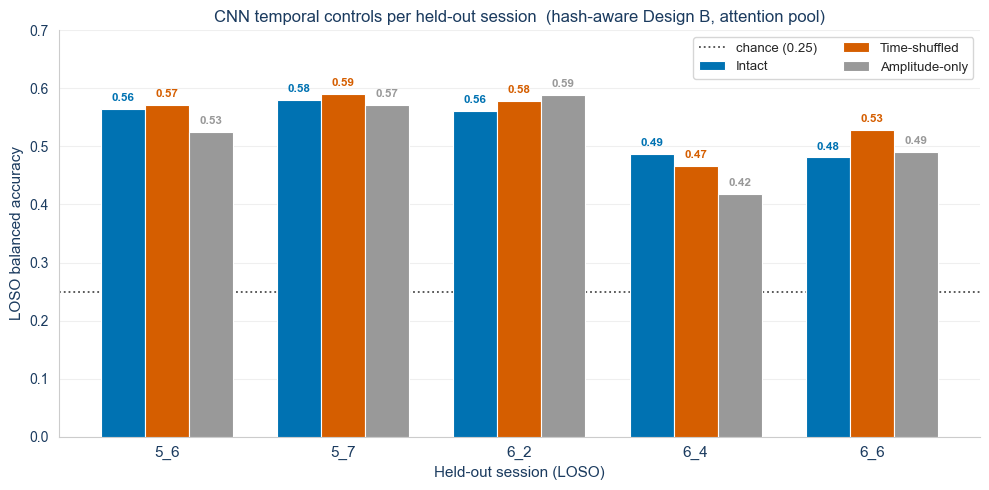

Saved: reports/figures/phase2_loso_temporal_controls_per_session.png


In [9]:
# Per-session grouped comparison: each held-out session x the 3 control conditions.
# Reads from the saved parquet so it works on a fresh kernel.
from src.config import FIGURES_DIR
import seaborn as sns
sns.set_style('whitegrid')

df_scores = pd.read_parquet(PROCESSED_RESULTS_DIR / 'phase2_loso_temporal_controls.parquet')

W_BLUE, W_VERMILLION, W_GRAY = '#0072B2', '#D55E00', '#999999'
NAVY = '#1B3B5F'
cond_color = {'intact': W_BLUE, 'time_shuffled': W_VERMILLION, 'amplitude_only': W_GRAY}
cond_label = {'intact': 'Intact', 'time_shuffled': 'Time-shuffled',
              'amplitude_only': 'Amplitude-only'}

# pivot: rows = held-out session, columns = control condition
piv = (df_scores.pivot_table(index='test_session', columns='control',
                             values='balanced_accuracy')
       .reindex(BALANCED_SESSIONS)[CONTROLS])

fig, ax = plt.subplots(figsize=(10, 5))
n_cond  = len(CONTROLS)
bar_w   = 0.25
x       = np.arange(len(BALANCED_SESSIONS))
offsets = np.linspace(-(n_cond - 1) / 2, (n_cond - 1) / 2, n_cond) * bar_w

for i, control in enumerate(CONTROLS):
    vals = piv[control].values
    bars = ax.bar(x + offsets[i], vals, bar_w, label=cond_label[control],
                  color=cond_color[control], edgecolor='white', linewidth=0.8, zorder=3)
    for b, v in zip(bars, vals):
        if np.isfinite(v):
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=8.5,
                    color=cond_color[control], fontweight='bold')

ax.axhline(0.25, ls=':', color='black', alpha=0.7, lw=1.3, label='chance (0.25)')
ax.set_xticks(x)
ax.set_xticklabels(BALANCED_SESSIONS, fontsize=11, color=NAVY)
ax.set_xlabel('Held-out session (LOSO)', fontsize=11, color=NAVY)
ax.set_ylabel('LOSO balanced accuracy', fontsize=11, color=NAVY)
ax.set_ylim(0, max(0.70, float(np.nanmax(piv.values)) + 0.08))
ax.set_title('CNN temporal controls per held-out session  '
             '(hash-aware Design B, attention pool)', fontsize=12, color=NAVY)
ax.tick_params(colors=NAVY)
ax.legend(loc='upper right', fontsize=9.5, ncol=2)
ax.grid(axis='y', alpha=0.3, zorder=1)
ax.grid(axis='x', visible=False)
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
for sp in ['left', 'bottom']: ax.spines[sp].set_color('#CCCCCC')

plt.tight_layout()
fig_path2 = FIGURES_DIR / 'phase2_loso_temporal_controls_per_session.png'
plt.savefig(fig_path2, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {fig_path2}')


## 8 · Persist results

In [10]:
# Per-fold results are already saved incrementally by the training cell.
# Here we just (re)save the compact summary.
summary_out = summary.reset_index()
summary_out.to_parquet(PROCESSED_RESULTS_DIR / 'phase2_loso_temporal_controls_summary.parquet')
print('Saved summary -> phase2_loso_temporal_controls_summary.parquet')
print(f'Per-fold results already at -> {PROCESSED_RESULTS_DIR / "phase2_loso_temporal_controls.parquet"}')


Saved summary -> phase2_loso_temporal_controls_summary.parquet
Per-fold results already at -> data/processed/results/phase2_loso_temporal_controls.parquet


## 9 · Reading the result

This notebook closes the gap flagged in the presentation: the time-shuffled and
amplitude-only controls are now run on the **same architecture** (hash-aware
Design B, attention pool) and the **same population** (5 balanced sessions,
LOSO) as the CNN headline.

- If `intact ≈ time_shuffled ≈ amplitude_only` (all three within ~1 pp), the
  conclusion *"temporal order is not the source of the CNN's layer signal"*
  holds for the headline architecture, not just the simple Design-A baseline.
- If `time_shuffled` drops clearly below `intact`, the hash-aware CNN **does**
  exploit temporal kinetics — and the presentation claim must be narrowed.
- The `amplitude_only` bar is the strongest control: if it matches `intact`,
  the CNN is using nothing beyond a per-trace scalar.

**Output files**
- `data/processed/results/phase2_loso_temporal_controls.parquet`
- `data/processed/results/phase2_loso_temporal_controls_summary.parquet`
- `reports/figures/phase2_loso_temporal_controls.png`
